# Downstream Analysis

This notebook performs the simplified downstream analysis after Steinbock processing.

Required inputs:

```text
results/08_cells.csv
data/neighbors/*.csv
```

Final outputs:

```text
results/12_cell_qc_summary.csv
results/13_cells_with_phenotypes.csv
results/14_phenotype_composition_by_category.csv
results/15_phenotype_spatial_interactions.csv
results/16_phenotype_spatial_enrichment.csv
figures/01_cell_counts_by_category.png
figures/02_phenotype_composition_by_category.png
figures/03_spatial_enrichment_heatmap.png
```

Methodological boundary:

The full template study used model-based phenotyping and advanced spatial modeling. This notebook provides a clean representative-subset analysis with transparent rule-based phenotyping and phenotype-aware spatial summaries.

## Step 0: Configure Workflow Paths

In [1]:
from pathlib import Path
import subprocess
import pandas as pd
from IPython.display import Image, display

def find_workflow_dir(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'data').exists() and (candidate / 'scripts').exists() and (candidate / 'results').exists():
            return candidate
    raise FileNotFoundError('Could not locate step_by_step_reproduction workflow directory.')

WORKFLOW_DIR = find_workflow_dir(Path.cwd())
SCRIPTS_DIR = WORKFLOW_DIR / 'scripts'
RESULTS_DIR = WORKFLOW_DIR / 'results'
FIGURES_DIR = WORKFLOW_DIR / 'figures'

print('Workflow directory:', WORKFLOW_DIR)

Workflow directory: /Users/rashid/1_IMC_Analysis/12_workflowIMC/step_by_step_reproduction


## Step 1: Run Clean Downstream Analysis

This single script performs QC, phenotyping, phenotype composition, and spatial interaction analysis.

Reusable script:

```text
scripts/09_clean_downstream_analysis.py
```

In [2]:
cmd = [
    'python3',
    str(SCRIPTS_DIR / '09_clean_downstream_analysis.py'),
    '--workflow-dir', str(WORKFLOW_DIR),
    '--cells-csv', 'results/08_cells.csv',
    '--neighbors-dir', 'data/neighbors',
    '--threshold-quantile', '0.75',
    '--cofactor', '1',
]

result = subprocess.run(cmd, cwd=WORKFLOW_DIR, text=True, capture_output=True, check=True)
print(result.stdout)

Clean downstream analysis complete.
results/12_cell_qc_summary.csv
results/13_cells_with_phenotypes.csv
results/14_phenotype_composition_by_category.csv
results/15_phenotype_spatial_interactions.csv
results/16_phenotype_spatial_enrichment.csv
figures/01_cell_counts_by_category.png
figures/02_phenotype_composition_by_category.png
figures/03_spatial_enrichment_heatmap.png



## Step 2: Review Final Tables

In [3]:
qc_summary = pd.read_csv(RESULTS_DIR / '12_cell_qc_summary.csv')
composition = pd.read_csv(RESULTS_DIR / '14_phenotype_composition_by_category.csv')
spatial_interactions = pd.read_csv(RESULTS_DIR / '15_phenotype_spatial_interactions.csv')
spatial_enrichment = pd.read_csv(RESULTS_DIR / '16_phenotype_spatial_enrichment.csv')

display(qc_summary)
display(composition)
display(spatial_interactions)
display(spatial_enrichment)

,metric,group,value
0,cells,all,71462
1,images,all,15
2,categories,all,3
3,marker_columns,all,42
4,cells_by_category,B,30523
5,cells_by_category,MGUS,31530
6,cells_by_category,UB,9409


,category,phenotype,cell_count,fraction
0,B,myeloid_macrophage_like,3432,0.112440
1,B,plasma_myeloma_like,2813,0.092160
2,B,proliferating_like,3392,0.111129
3,B,stromal_bone_like,1142,0.037414
4,B,t_cell_like,5860,0.191986
5,B,unassigned,13884,0.454870
6,MGUS,myeloid_macrophage_like,4523,0.143451
7,MGUS,plasma_myeloma_like,5799,0.183920
8,MGUS,proliferating_like,2180,0.069141
9,MGUS,stromal_bone_like,2465,0.078180


,phenotype_a,phenotype_b,edge_count,edge_fraction
0,myeloid_macrophage_like,myeloid_macrophage_like,13250,0.037510
1,myeloid_macrophage_like,plasma_myeloma_like,13778,0.039005
2,myeloid_macrophage_like,proliferating_like,6504,0.018413
3,myeloid_macrophage_like,stromal_bone_like,10304,0.029170
4,myeloid_macrophage_like,t_cell_like,19058,0.053952
5,myeloid_macrophage_like,unassigned,20072,0.056823
6,plasma_myeloma_like,plasma_myeloma_like,22730,0.064348
7,plasma_myeloma_like,proliferating_like,6848,0.019386
8,plasma_myeloma_like,stromal_bone_like,13056,0.036961
9,plasma_myeloma_like,t_cell_like,19092,0.054049


,phenotype_a,phenotype_b,observed_edges,expected_edges,observed_expected_ratio
0,myeloid_macrophage_like,myeloid_macrophage_like,13250,6264.944422,2.114943
1,myeloid_macrophage_like,plasma_myeloma_like,13778,14872.084100,0.926434
2,myeloid_macrophage_like,proliferating_like,6504,7992.955256,0.813717
3,myeloid_macrophage_like,stromal_bone_like,10304,9389.846300,1.097356
4,myeloid_macrophage_like,t_cell_like,19058,20470.180913,0.931013
5,myeloid_macrophage_like,unassigned,20072,28830.461900,0.696208
6,plasma_myeloma_like,plasma_myeloma_like,22730,8826.051381,2.575331
7,plasma_myeloma_like,proliferating_like,6848,9487.067623,0.721825
8,plasma_myeloma_like,stromal_bone_like,13056,11145.077630,1.171459
9,plasma_myeloma_like,t_cell_like,19092,24296.644278,0.785788


## Step 3: Review Final Figures

figures/01_cell_counts_by_category.png


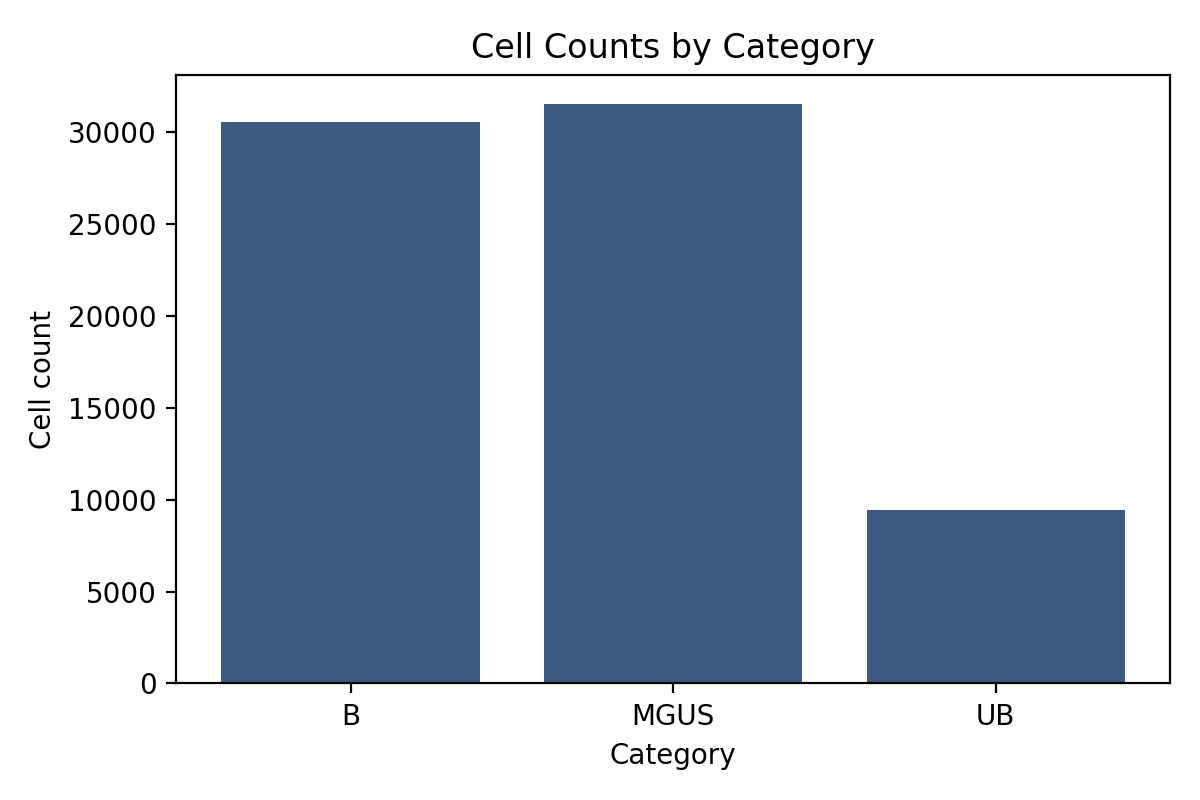

figures/02_phenotype_composition_by_category.png


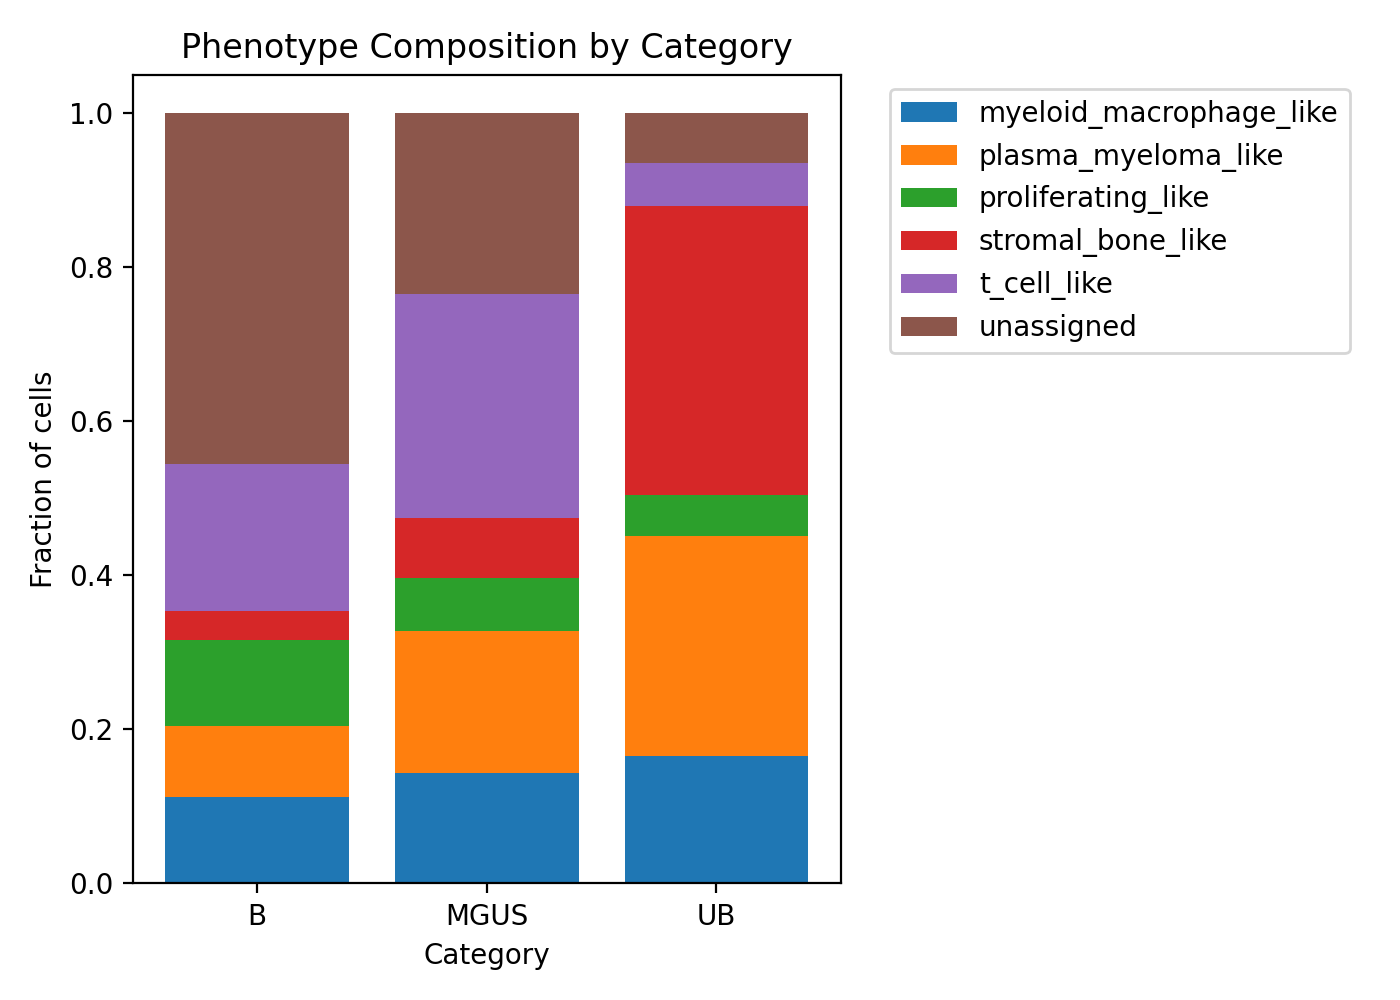

figures/03_spatial_enrichment_heatmap.png


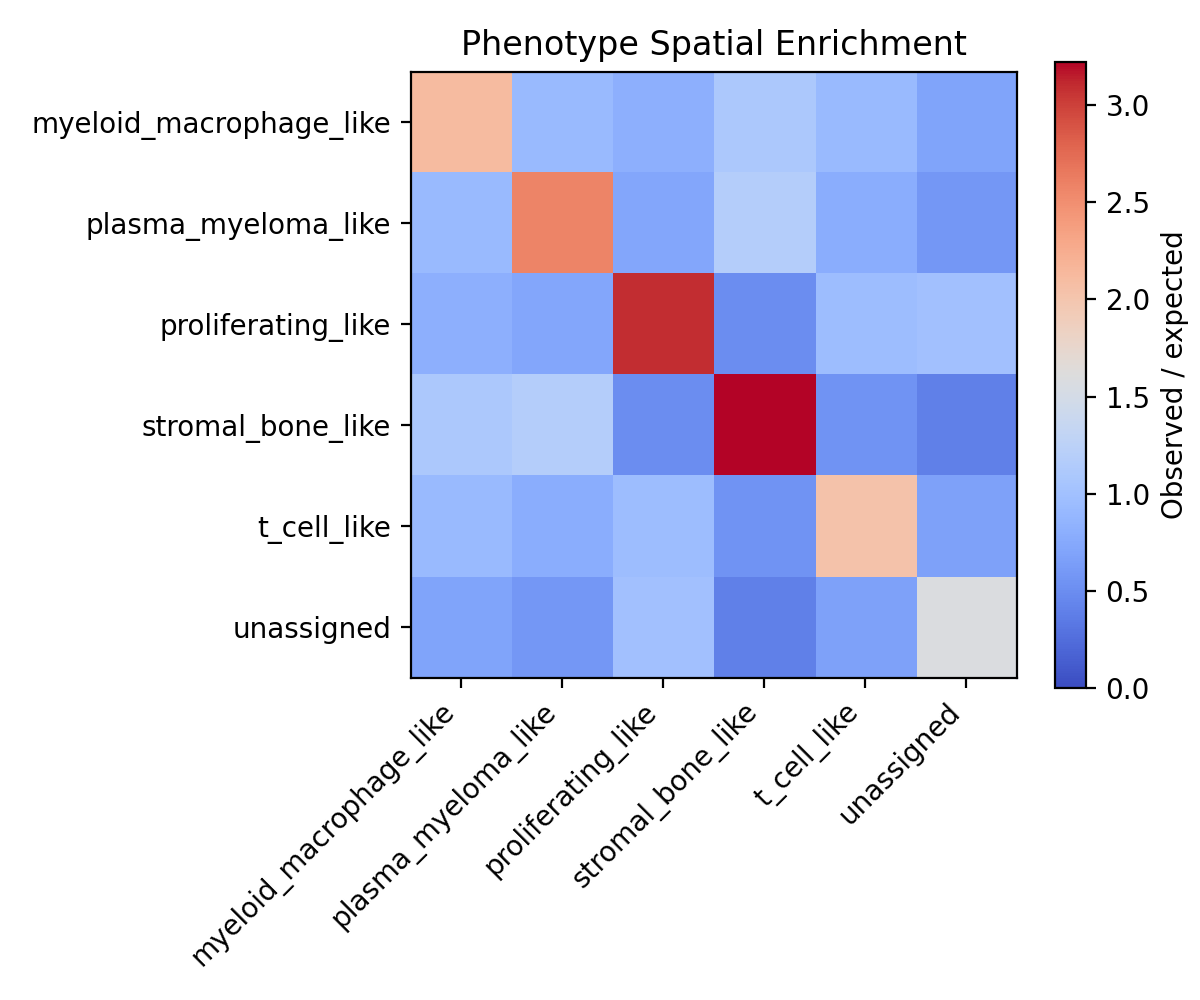

In [4]:
for figure in [
    FIGURES_DIR / '01_cell_counts_by_category.png',
    FIGURES_DIR / '02_phenotype_composition_by_category.png',
    FIGURES_DIR / '03_spatial_enrichment_heatmap.png',
]:
    print(figure.relative_to(WORKFLOW_DIR))
    display(Image(filename=str(figure)))

## Step 4: Output Checklist

In [5]:
expected_outputs = [
    RESULTS_DIR / '12_cell_qc_summary.csv',
    RESULTS_DIR / '13_cells_with_phenotypes.csv',
    RESULTS_DIR / '14_phenotype_composition_by_category.csv',
    RESULTS_DIR / '15_phenotype_spatial_interactions.csv',
    RESULTS_DIR / '16_phenotype_spatial_enrichment.csv',
    FIGURES_DIR / '01_cell_counts_by_category.png',
    FIGURES_DIR / '02_phenotype_composition_by_category.png',
    FIGURES_DIR / '03_spatial_enrichment_heatmap.png',
]

for path in expected_outputs:
    print(path.relative_to(WORKFLOW_DIR), path.exists())

results/12_cell_qc_summary.csv True
results/13_cells_with_phenotypes.csv True
results/14_phenotype_composition_by_category.csv True
results/15_phenotype_spatial_interactions.csv True
results/16_phenotype_spatial_enrichment.csv True
figures/01_cell_counts_by_category.png True
figures/02_phenotype_composition_by_category.png True
figures/03_spatial_enrichment_heatmap.png True
